In [1]:
# Cell 1: Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import seaborn as sns
print("Libraries imported successfully")

I0000 00:00:1778342300.985243   22976 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully


Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


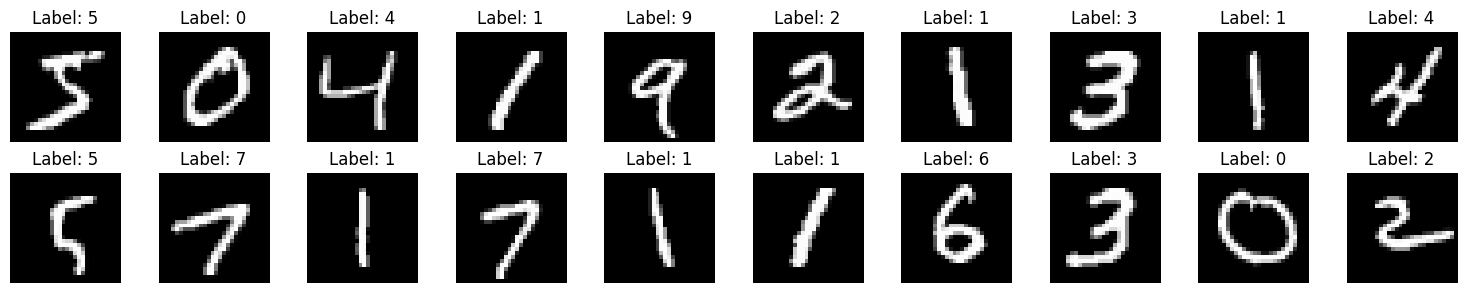

In [2]:
# Cell 2: Load and Visualize MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# CREATE OUTPUT DIRECTORY (ADD THIS)
import os
os.makedirs('output', exist_ok=True)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Visualize sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(x_train[i], cmap='gray')
    axes[0, i].set_title(f'Label: {y_train[i]}')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train[i+100], cmap='gray')
    axes[1, i].set_title(f'Label: {y_train[i+100]}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('output/mnist_samples.png')
plt.show()

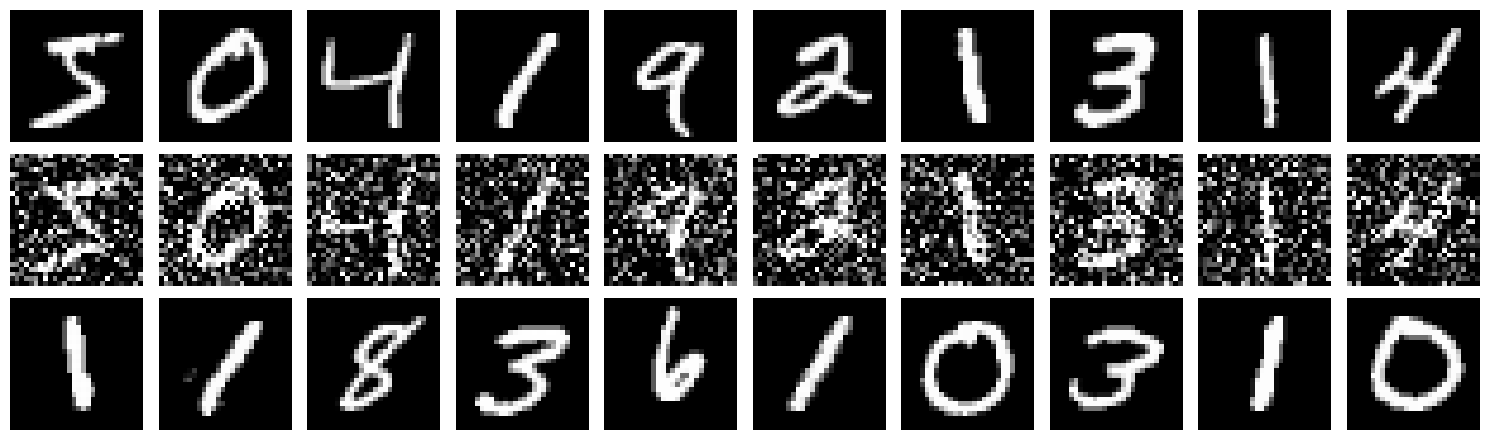

In [3]:
# Cell 3: Data Preparation - Flatten and Noisy Data
# For vanilla autoencoder - flatten
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Create noisy data for denoising AE (Gaussian noise)
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Visualize original vs noisy
fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
for i in range(10):
    axes[0, i].imshow(x_train[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i], cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(x_train[i+200], cmap='gray')  # original shifted
    axes[2, i].axis('off')
plt.tight_layout()
plt.savefig('output/original_noisy.png')
plt.show()  

In [4]:
# Cell 4: Vanilla Autoencoder Architecture
latent_dim = 32

# Encoder
encoder_inputs = keras.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
z = layers.Dense(latent_dim)(x)  # latent space
encoder = keras.Model(encoder_inputs, z, name='vanilla_encoder')
encoder.summary()

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(latent_inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
decoder_outputs = layers.Dense(784, activation='sigmoid')(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name='vanilla_decoder')
decoder.summary()

# Autoencoder
autoencoder_inputs = keras.Input(shape=(784,))
encoded = encoder(autoencoder_inputs)
decoded = decoder(encoded)
vanilla_ae = keras.Model(autoencoder_inputs, decoded)
vanilla_ae.summary()


W0000 00:00:1778342311.527006   22976 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "vanilla_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,272 (2.18 MB)

 Trainable params: 570,272 (2.18 MB)

...

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_encoder (Functional)    │ (None, 32)             │       570,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vanilla_decoder (Functional)    │ (None, 784)            │       571,024 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,296 (4.35 MB)

 Trainable params: 1,141,296 (4.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.0507 - val_loss: 0.0257
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0210 - val_loss: 0.0170
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0156 - val_loss: 0.0142
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0133 - val_loss: 0.0129
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0117 - val_loss: 0.0110
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0107 - val_loss: 0.0102
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0099 - val_loss: 0.0095
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0093 - val_loss: 0.0091
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0088 - val_loss: 0.0087
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0084 - val_loss: 0.0082
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0080 - val_loss: 0.0078
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━

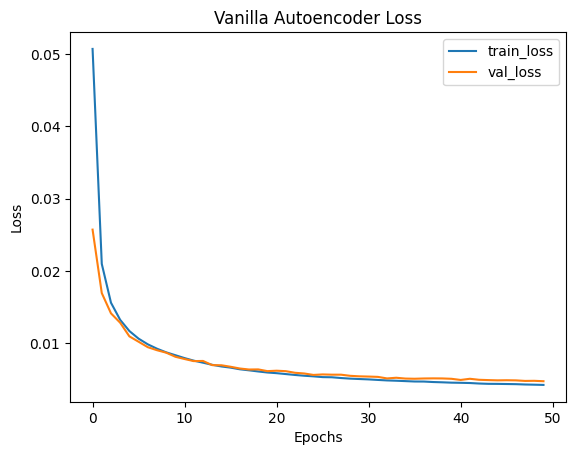

In [5]:
# Cell 5: Train Vanilla Autoencoder
vanilla_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

history_vanilla = vanilla_ae.fit(x_train_flat, x_train_flat,
                                 epochs=50,
                                 batch_size=256,
                                 shuffle=True,
                                 validation_data=(x_test_flat, x_test_flat),
                                 verbose=1)

# Plot training loss
plt.plot(history_vanilla.history['loss'], label='train_loss')
plt.plot(history_vanilla.history['val_loss'], label='val_loss')
plt.title('Vanilla Autoencoder Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('output/vanilla_loss.png')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


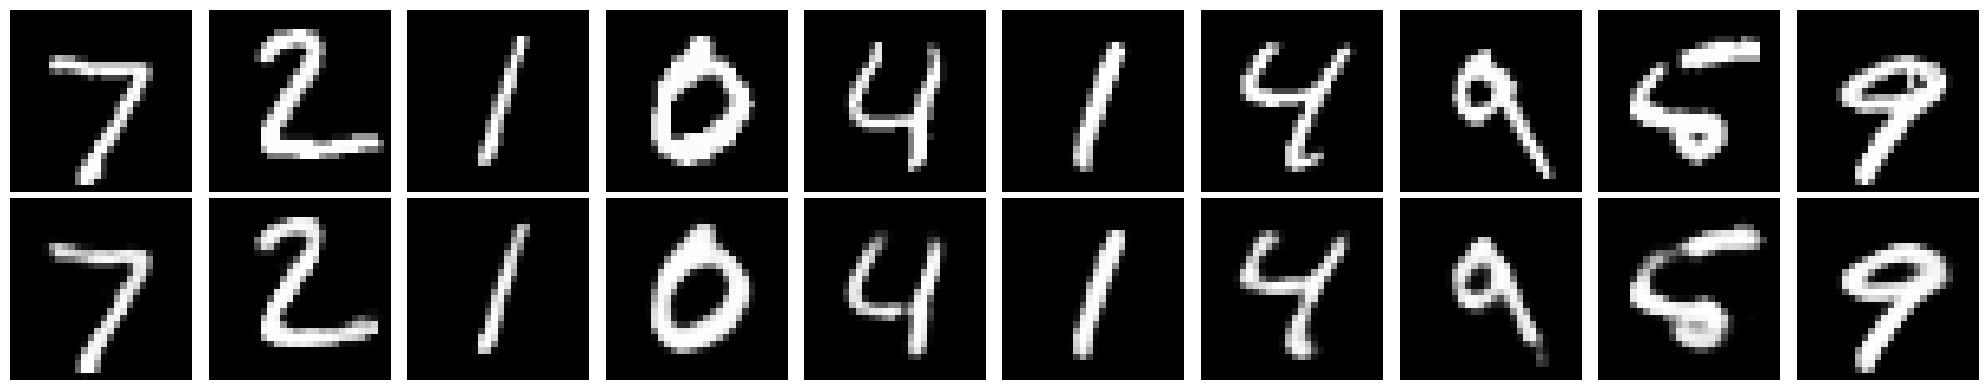

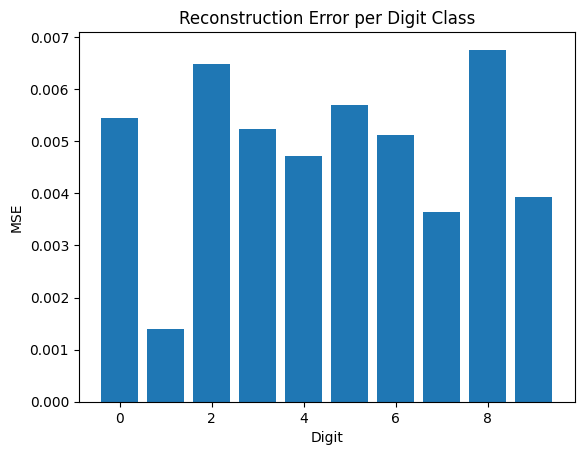

In [6]:
# Cell 6: Evaluate Vanilla Autoencoder - Reconstructions
decoded_imgs = vanilla_ae.predict(x_test_flat)

# Visualize original vs reconstructed
n = 10
fig, axes = plt.subplots(2, n, figsize=(20, 4))
for i in range(n):
    # Original
    axes[0, i].imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    # Reconstructed
    axes[1, i].imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('output/vanilla_reconstructions.png')
plt.show()

# Reconstruction error per class
recon_errors = np.mean((x_test_flat - decoded_imgs)**2, axis=1)
class_errors = [np.mean(recon_errors[y_test == c]) for c in range(10)]
plt.bar(range(10), class_errors)
plt.title('Reconstruction Error per Digit Class')
plt.xlabel('Digit')
plt.ylabel('MSE')
plt.savefig('output/class_errors_vanilla.png')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


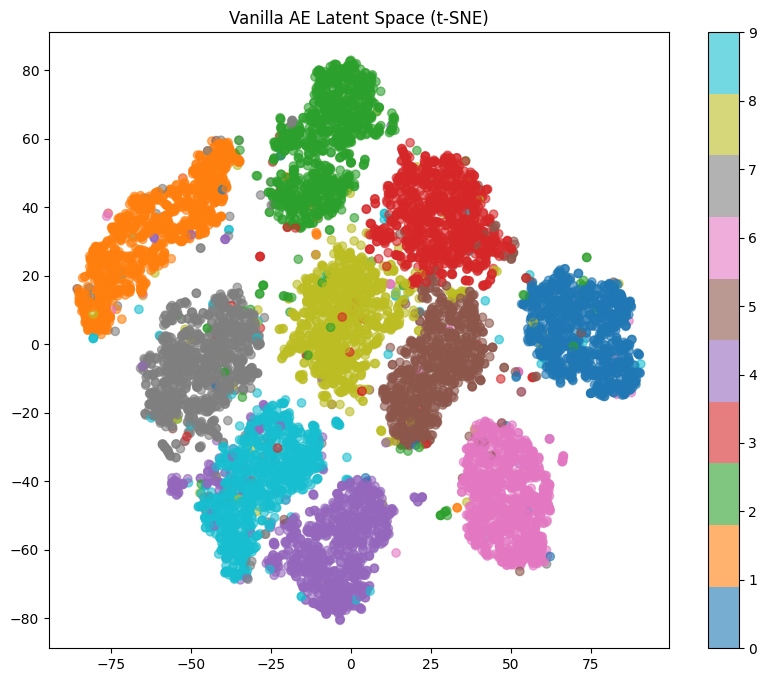

In [7]:
# Cell 7: Latent Space Visualization (Vanilla)
z_test = encoder.predict(x_test_flat)
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z_test)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_test, cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.title('Vanilla AE Latent Space (t-SNE)')
plt.savefig('output/vanilla_latent_tsne.png')
plt.show()


In [8]:
# Cell 8: Convolutional Autoencoder Architecture (FIXED)
input_img = keras.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)   # 28 -> 14
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)   # 14 -> 7
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
shape_before_flatten = tf.keras.backend.int_shape(x)  # (7, 7, 128)

x = layers.Flatten()(x)
latent = layers.Dense(16, name='latent_vector')(x)

conv_encoder = keras.Model(input_img, latent, name='conv_encoder')
conv_encoder.summary()

# Decoder
latent_input = keras.Input(shape=(16,))
x = layers.Dense(shape_before_flatten[1] * shape_before_flatten[2] * shape_before_flatten[3], activation='relu')(latent_input)
x = layers.Reshape((shape_before_flatten[1], shape_before_flatten[2], shape_before_flatten[3]))(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)   # 7 -> 14
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)   # 14 -> 28
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

conv_decoder = keras.Model(latent_input, decoded, name='conv_decoder')
conv_decoder.summary()

# Autoencoder
conv_ae_inputs = keras.Input(shape=(28, 28, 1))
encoded = conv_encoder(conv_ae_inputs)
decoded_output = conv_decoder(encoded)
conv_ae = keras.Model(conv_ae_inputs, decoded_output, name='conv_autoencoder')
conv_ae.summary()

Model: "conv_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 16)             │       100,368 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,040 (754.06 KB)

 Trainable params: 193,040 (754.06 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_encoder (Functional)       │ (None, 16)             │       193,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_decoder (Functional)       │ (None, 28, 28, 1)      │       346,753 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,793 (2.06 MB)

 Trainable params: 539,793 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - loss: 0.1140 - val_loss: 0.1140
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 196s 832ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 197s 840ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 197s 840ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 203s 862ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 203s 865ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 203s 864ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 204s 867ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 204s 867ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - loss: 0.1120 - val_loss: 0.1140
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - loss: 0.1120 - val_loss: 0.1140
Epoch 12/50
235/2

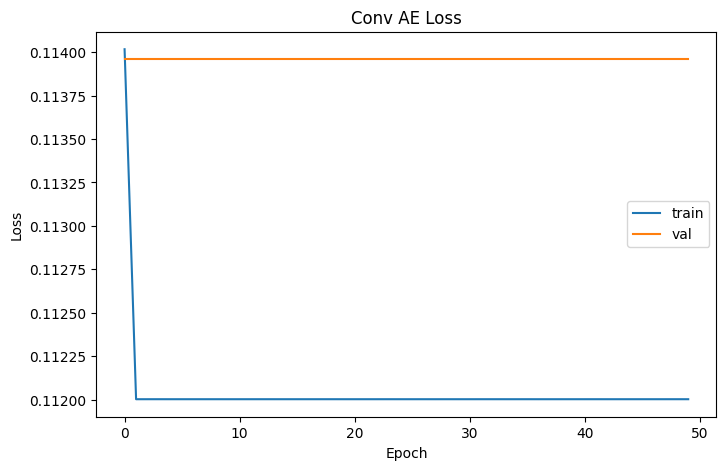

In [9]:
# Cell 9: Train Convolutional Autoencoder
x_train_reshaped = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test_reshaped = x_test.reshape((x_test.shape[0], 28, 28, 1))

conv_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

history_conv = conv_ae.fit(
    x_train_reshaped, x_train_reshaped,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_reshaped, x_test_reshaped),
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history_conv.history['loss'], label='train')
plt.plot(history_conv.history['val_loss'], label='val')
plt.title('Conv AE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('output/conv_loss.png')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


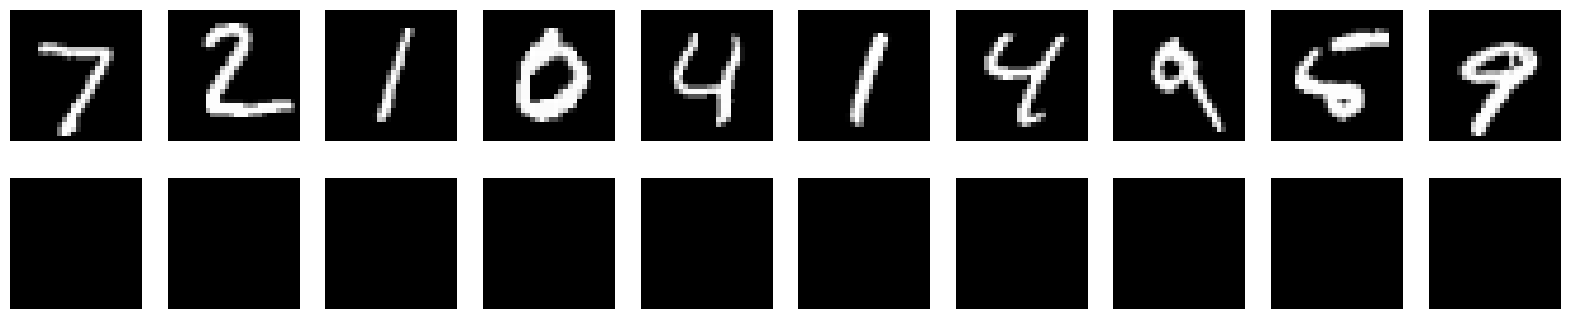

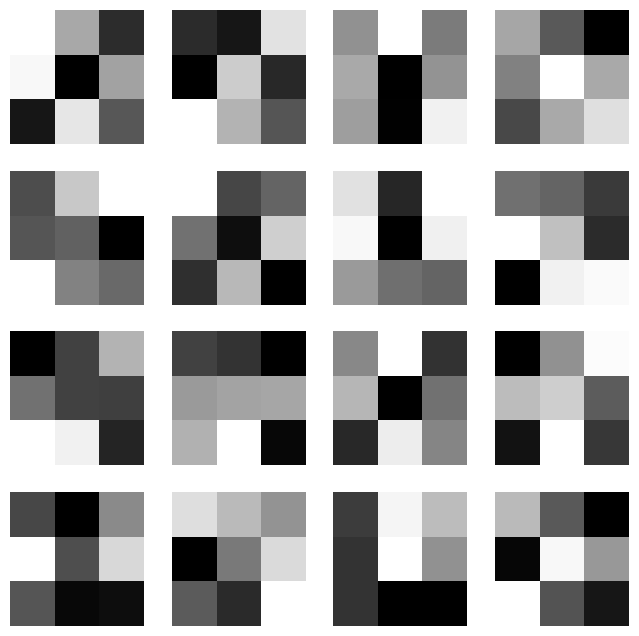

In [10]:
# Cell 10: Evaluate Conv AE - Reconstructions and Filters
decoded_conv = conv_ae.predict(x_test_reshaped)

n = 10
fig, axes = plt.subplots(2, n, figsize=(20, 4))
for i in range(n):
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(decoded_conv[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
plt.savefig('output/conv_reconstructions.png')
plt.show()

# Visualize filters
filters = conv_encoder.layers[1].get_weights()[0][:,:,0,:16]  # first conv, first channel
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(16):
    axes[i//4, i%4].imshow(filters[:,:,i], cmap='gray')
    axes[i//4, i%4].axis('off')
plt.savefig('output/conv_filters.png')
plt.show()


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - loss: 0.1120 - val_loss: 0.1140
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 223s 947ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 187s 797ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 167s 713ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 170s 721ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 194s 825ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 198s 841ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 223s 947ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - loss: 0.1120 - val_loss: 0.1140
Epoch 12/50
235/235 

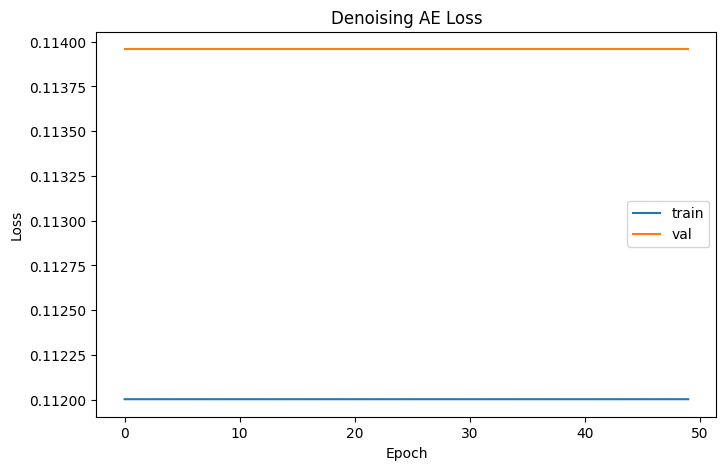

In [12]:
# Cell 11: Denoising Autoencoder (RECREATE MODEL - FIXED)
# Use the newly fixed conv_ae architecture
denoising_ae = keras.Model(conv_ae.input, conv_ae.output, name='denoising_ae')
denoising_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Reshape noisy data
x_train_noisy_reshaped = x_train_noisy.reshape((x_train_noisy.shape[0], 28, 28, 1))
x_test_noisy_reshaped = x_test_noisy.reshape((x_test_noisy.shape[0], 28, 28, 1))

history_denoise = denoising_ae.fit(
    x_train_noisy_reshaped, x_train_reshaped,  # noisy input, clean target
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy_reshaped, x_test_reshaped),
    verbose=1
)

plt.figure(figsize=(8,5))
plt.plot(history_denoise.history['loss'], label='train')
plt.plot(history_denoise.history['val_loss'], label='val')
plt.title('Denoising AE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('output/denoise_loss.png')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


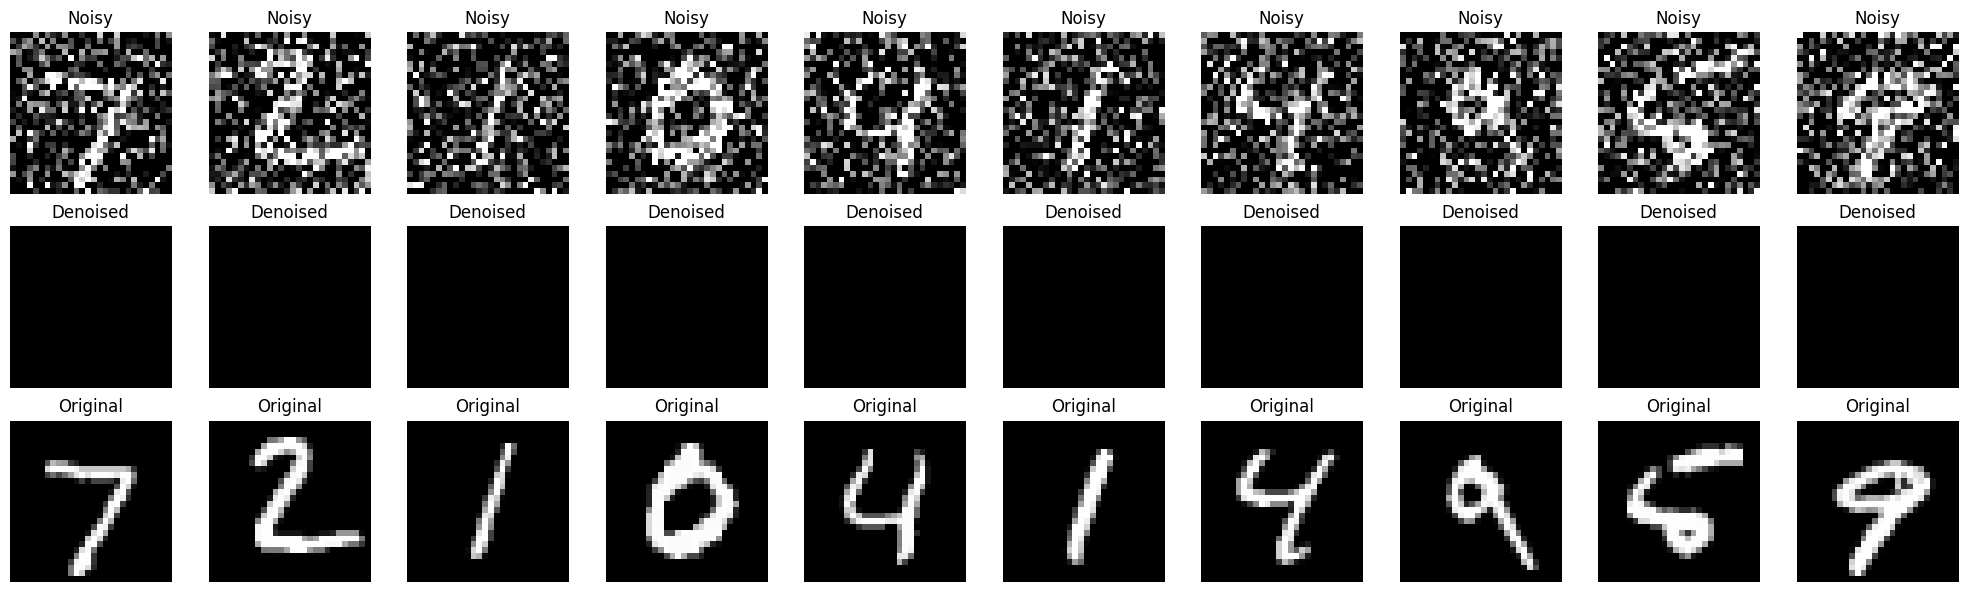

Avg PSNR: 10.23 dB
Avg SSIM: 0.2589


In [13]:
# Cell 12: Evaluate Denoising - Visuals and Metrics
denoised_imgs = denoising_ae.predict(x_test_noisy_reshaped)

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(x_test_noisy[i], cmap='gray')
    axes[0, i].set_title('Noisy')
    axes[0, i].axis('off')
    axes[1, i].imshow(denoised_imgs[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Denoised')
    axes[1, i].axis('off')
    axes[2, i].imshow(x_test[i], cmap='gray')
    axes[2, i].set_title('Original')
    axes[2, i].axis('off')
plt.tight_layout()
plt.savefig('output/denoising_results.png')
plt.show()

# PSNR and SSIM
psnrs = [psnr(x_test[i], denoised_imgs[i].reshape(28,28)) for i in range(100)]
ssims = [ssim(x_test[i], denoised_imgs[i].reshape(28,28), data_range=1.0) for i in range(100)]
print(f"Avg PSNR: {np.mean(psnrs):.2f} dB")
print(f"Avg SSIM: {np.mean(ssims):.4f}")


In [15]:
# Cell 13: Comparative Table (MSE for vanilla and conv)
mse_vanilla = np.mean((x_test_flat - decoded_imgs)**2)
mse_conv = np.mean((x_test_reshaped.reshape(-1,784) - decoded_conv.reshape(-1,784))**2)
print(f"Vanilla MSE: {mse_vanilla:.4f}")
print(f"Conv MSE: {mse_conv:.4f}")

comparison_data = {
    'Model': ['Vanilla', 'Conv', 'Denoising'],
    'Latent Dim': [32, 16, 16],
    'Reconstruction Loss': [f"{mse_vanilla:.4f}", f"{mse_conv:.4f}", 'N/A (PSNR)'],
    'Best Use': ['Dense data', 'Image data', 'Noise removal']
}
import pandas as pd
df = pd.DataFrame(comparison_data)
print(df.to_markdown())
df.to_csv('output/comparison.csv')


Vanilla MSE: 0.0048
Conv MSE: 0.1140
|    | Model     |   Latent Dim | Reconstruction Loss   | Best Use      |
|---:|:----------|-------------:|:----------------------|:--------------|
|  0 | Vanilla   |           32 | 0.0048                | Dense data    |
|  1 | Conv      |           16 | 0.1140                | Image data    |
|  2 | Denoising |           16 | N/A (PSNR)            | Noise removal |
